# Experiment around with sum trees

In [3]:
import numpy as np

capa = 4
tree = np.zeros(2**capa - 1)

tree

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [4]:
import numpy as np


class SumTree:
    """Data structure to store priorities of transitions. Recommended by:
    Schaul, Tom. "Prioritized Experience Replay." arXiv preprint arXiv:1511.05952 (2015).

    Following properties:
    - Binary tree
    - Parent node = Sum of child nodes
    - Leaf nodes = Priorities of transitions
    - Update in O(log n)
    - Sample in O(log n)
    """

    def __init__(self, capacity):
        """Initialize the SumTree object.

        Variables:
        - capacity: Capacity of the SumTree
        - tree: Array to store the SumTree, where the index represents a node
                shape = 2 * capacity - 1 (max size of the tree)
        - data: Array to store the transitions/data behind each leaf node
        - size: Current size of the SumTree (max = capacity)
        - current_idx: Current index to add new transitions (circular buffer)

        Args:
            capacity (int): Capacity of the SumTree.
        """
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1)
        self.data = np.zeros(capacity, dtype=object)
        self.size = 0
        self.current_idx = 0

    def add(self, priority, data):
        """Add a new priority and data to the SumTree.
        If the SumTree is full, the oldest transition is replaced.
        Priority is added to the leaf node and propagated to the parent nodes.

        Args:
            priority (float): Priority of the transition.
            data (object): Data of the transition.
        """
        idx = self.current_idx + self.capacity - 1
        self.data[self.current_idx] = data
        self.update(idx, priority)
        self.current_idx = (self.current_idx + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def get_all_leafs(self):
        """Get all the leafs of the SumTree. Which are filled with data."""
        return self.tree[self.leaf2global(0) : self.leaf2global(self.size)], self.data

    def max(self):
        """Get the maximum priority in the SumTree."""
        return np.max(self.tree[-self.capacity :])

    def total(self):
        """Get the total sum of priorities."""
        return self.tree[0]

    def get_leafs(self, indices: np.array) -> tuple[np.array, np.array]:
        """Get the leafs of the SumTree based on indices.

        Args:
            indices (np.array): Array of indices.

        Returns:
            tuple: (tree, data) of the leafs.
        """
        return self.tree[indices], self.data[indices - (self.capacity - 1)]

    def leaf2global(self, leaf):
        """Convert a leaf index to a global index.

        Args:
            leaf (int): Index of the leaf node.

        Returns:
            int: Index of the global node.
        """
        return leaf + self.capacity - 1

    def update(self, index, priority):
        """Update the priority of a transition.
        Where the change = new priority - old priority.
        Propagate the change to the parent nodes.

        Args:
            index (int): Index of the transition.
            priority (float): New priority of the transition.
        """
        # Handle negative index
        if index < 0:
            index = len(self.tree) + index

        change = priority - self.tree[index]
        self.tree[index] = priority
        self._propagate(index, change)

    def update_leaf(self, leaf, priority):
        """Update the priority of a transition based on the leaf index.

        Args:
            leaf (int): Index of the leaf node.
            priority (float): New priority of the transition.
        """
        index = self.leaf2global(leaf)
        self.update(index, priority)

    def _propagate(self, index, change):
        """Propagate the change in priority to the parent nodes.
        Takes the parent node and adds the change to the node.

        New parent = (index - 1) // 2 --> Based on array

        Args:
            index (int): Index of the transition.
            change (float): Change in priority.
        """
        parent = (index - 1) // 2
        while parent >= 0:
            self.tree[parent] += change
            parent = (parent - 1) // 2

    def _retrieve(self, index, s):
        """Retrieve the index of a transition based on a sample.

        Args:
            index (int): Index of the transition.
            s (float): Sample value.
        """
        left = 2 * index + 1
        right = left + 1

        while left < len(self.tree):
            if s <= self.tree[left]:
                index = left
            else:
                s -= self.tree[left]
                index = right
            left = 2 * index + 1
            right = left + 1

        return index

    def sample(self, s):
        """Retrieve the index, priority, and data of a transition based on a sample value.

        Args:
            s (float): A random value between 0 and the total sum of priorities.

        Returns:
            tuple: (index, priority, data) of the sampled transition.
        """
        index = 0  # Start at the root node

        # Traverse the tree to find the leaf node
        while index < self.capacity - 1:  # While the index is not a leaf node
            left_child = 2 * index + 1
            right_child = left_child + 1

            if s <= self.tree[left_child] or self.tree[right_child] == 0:
                index = left_child
            elif s > self.tree[left_child] or self.tree[left_child] == 0:
                s -= self.tree[left_child]
                index = right_child
            else:
                raise ValueError("Invalid index")

        # Convert the leaf index to the data index
        leaf_index = index - (self.capacity - 1)
        priority = self.tree[index]
        data = self.data[leaf_index]

        return index, priority, data

    def sample_batch(self, batch_size: int) -> tuple[list, list, list]:
        """Sample a batch of transitions from the SumTree.


        Args:
            batch_size (int): Number of transitions to sample.

        Returns:
            tuple: Batch of transitions (indices, priorities, data).
        """
        if self.size < batch_size:
            raise ValueError("The memory buffer is too small for the batch size.")

        batch = [[], [], []]  # Index, Priority, Data
        segment = self.tree[0] / batch_size

        for i in range(batch_size):
            a = segment * i
            b = segment * (i + 1)
            s = np.random.uniform(a, b)
            index, priority, data = self.sample(s)
            batch[0].append(index)
            batch[1].append(priority)
            batch[2].append(data)

        return (*batch,)

    def get_sum(self):
        """Get the total sum of priorities."""
        return self.tree[0]

    def display_tree(self):
        """Display a NumPy array as a tree structure using for loops."""
        array = self.tree
        if len(array) == 0:
            print("The tree is empty.")
            return

        # Initialize the current level and the index for the next node to print
        current_level = 0
        index = 0
        level_count = 1  # Number of nodes at the current level

        while index < len(array):
            # Print the current level nodes
            for i in range(level_count):
                if index < len(array):
                    print(array[index], end=" ")
                    index += 1

            print()

            # Update the level count for the next level (2^current_level)
            level_count *= 2
            current_level += 1

## Test around and debug

#### Create

In [5]:
sum_tree = SumTree(4)
sum_tree.add(1, "a")
sum_tree.add(2, "b")
sum_tree.add(3, "c")
sum_tree.add(4, "d")

sum_tree.display_tree(), sum_tree.tree, sum_tree.data

10.0 
3.0 7.0 
1.0 2.0 3.0 4.0 


(None,
 array([10.,  3.,  7.,  1.,  2.,  3.,  4.]),
 array(['a', 'b', 'c', 'd'], dtype=object))

#### Overwrite

In [6]:
sum_tree.add(5, "e")

sum_tree.display_tree(), sum_tree.tree, sum_tree.data

14.0 
7.0 7.0 
5.0 2.0 3.0 4.0 


(None,
 array([14.,  7.,  7.,  5.,  2.,  3.,  4.]),
 array(['e', 'b', 'c', 'd'], dtype=object))

#### Update prio

In [7]:
sum_tree.update_leaf(1, 10)

sum_tree.display_tree(), sum_tree.tree, sum_tree.data

22.0 
15.0 7.0 
5.0 10.0 3.0 4.0 


(None,
 array([22., 15.,  7.,  5., 10.,  3.,  4.]),
 array(['e', 'b', 'c', 'd'], dtype=object))

In [8]:
sum_tree.update(-1, 10)

sum_tree.display_tree(), sum_tree.tree, sum_tree.data

28.0 
15.0 13.0 
5.0 10.0 3.0 10.0 


(None,
 array([28., 15., 13.,  5., 10.,  3., 10.]),
 array(['e', 'b', 'c', 'd'], dtype=object))

### Sample Priority Based

In [9]:
sampled = sum_tree.sample(16)
sampled

(5, 3.0, 'c')

In [10]:
sampled = sum_tree.sample_batch(2)
sampled

([4, 6], [10.0, 10.0], ['b', 'd'])

### Plot Priorities sampled

Time taken to add 10000000 transitions: 67.16 seconds
For 10000 Samples it took 0.07 seconds
Time taken to sample 100 batches of 256 transitions: 0.23 seconds
For 1 Batch it took 0.00 seconds


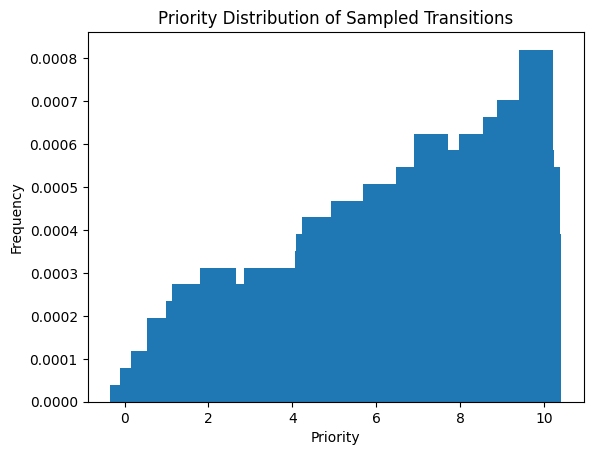

In [186]:
import time

N = int(10e6)

# Sample N batches of X transitions and measure the time, save all samples and plot the priority distribution
import matplotlib.pyplot as plt

# Add N transitions to the sum tree
sum_tree = SumTree(N)
start_time = time.time()
for i in range(N):
    prio = np.random.uniform(-10, 10)
    sum_tree.add(prio, f"transition_{i}")
end_time = time.time()
print(f"Time taken to add {N} transitions: {end_time - start_time:.2f} seconds")
print(f"For 10000 Samples it took {10000*(end_time - start_time)/N:.2f} seconds")

# Sample N batches of X transitions
num_batches = 100
batch_size = 256
samples = [[], [], []]

start_time = time.time()
for _ in range(num_batches):
    batch = sum_tree.sample_batch(batch_size)
    for i in range(3):
        samples[i].extend(batch[i])
end_time = time.time()

# Measure the time taken
time_taken = end_time - start_time
print(
    f"Time taken to sample {num_batches} batches of {batch_size} transitions: {time_taken:.2f} seconds"
)
print(f"For 1 Batch it took {time_taken/(num_batches*batch_size):.2f} seconds")

# Extract priorities from samples
priorities = samples[1]
num_occurrences = {p: priorities.count(p) for p in set(priorities)}

rel_freq = {p: num_occurrences[p] / len(priorities) for p in num_occurrences}

# Plot the priority distribution
plt.bar(rel_freq.keys(), rel_freq.values())
plt.title("Priority Distribution of Sampled Transitions")
plt.xlabel("Priority")
plt.ylabel("Frequency")
plt.show()

Time taken to add 10000000 transitions: 19.30 seconds
For 10000 Samples it took 0.02 seconds
Time taken to sample 100 batches of 256 transitions: 61.39 seconds
For 1 Batch it took 0.00 seconds


Text(0, 0.5, 'Frequency')

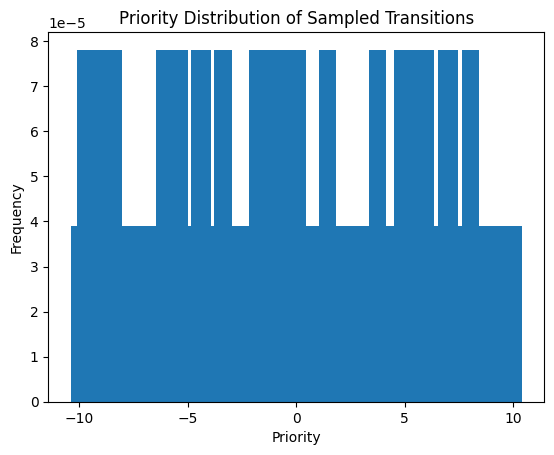

In [187]:
# Compared to standard replay buffer
from collections import deque

buffer = deque(maxlen=N)

# Add N transitions to the replay buffer
start_time = time.time()
for i in range(N):
    prio = np.random.uniform(-10, 10)
    buffer.append((prio, f"transition_{i}"))
end_time = time.time()
print(f"Time taken to add {N} transitions: {end_time - start_time:.2f} seconds")
print(f"For 10000 Samples it took {10000*(end_time - start_time)/N:.2f} seconds")

# Sample of X transitions
start_time = time.time()
samples = []
for _ in range(num_batches):
    idxs = np.random.choice(range(N), size=batch_size)
    batch = [buffer[i] for i in idxs]
    samples.extend(batch)
end_time = time.time()

# Measure the time taken
time_taken = end_time - start_time
print(
    f"Time taken to sample {num_batches} batches of {batch_size} transitions: {time_taken:.2f} seconds"
)
print(f"For 1 Batch it took {time_taken/(num_batches*batch_size):.2f} seconds")

# Extract priorities from samples
priorities = [b[0] for b in samples]
num_occurrences = {p: priorities.count(p) for p in set(priorities)}

rel_freq = {p: num_occurrences[p] / len(priorities) for p in num_occurrences}

# Plot the priority distribution
plt.bar(rel_freq.keys(), rel_freq.values())
plt.title("Priority Distribution of Sampled Transitions")
plt.xlabel("Priority")
plt.ylabel("Frequency")

## Structural test

In [276]:
tree = SumTree(10)
tree.add(1, "a")
tree.add(2, "b")

for _ in range(10000):
    s = tree.sample(np.random.uniform(0, tree.get_sum()))
    if s[1] != 1 and s[1] != 2:
        print(s)

In [34]:
tree = SumTree(10)
for i in range(4):
    data = np.array([[i, i + 1], [i + 2, i + 3]])
    tree.add(i, data)

tree.display_tree()
prios, data = tree.get_all_leafs()
props = np.array([p / tree.total() for p in prios])
s = np.random.choice(range(tree.size), 1, p=props)
s

s, data[s], prios[s], props[s]

6.0 
1.0 5.0 
0.0 1.0 5.0 0.0 
0.0 0.0 0.0 1.0 2.0 3.0 0.0 0.0 
0.0 0.0 0.0 0.0 


(array([2]),
 array([array([[2, 3],
               [4, 5]])], dtype=object),
 array([2.]),
 array([0.33333333]))

In [76]:
tree.update_leaf(1, 1)
prios, data = tree.get_all_leafs()
props = np.array([p / tree.total() for p in prios])
s = np.random.choice(range(tree.size), 8, p=props)
s

s, data[s], prios[s], props[s]

(array([2, 3, 2, 2, 3, 2, 3, 3]),
 array([array([[2, 3],
               [4, 5]]), array([[3, 4],
                                [5, 6]]), array([[2, 3],
                                                 [4, 5]]), array([[2, 3],
                                                                  [4, 5]]),
        array([[3, 4],
               [5, 6]]), array([[2, 3],
                                [4, 5]]), array([[3, 4],
                                                 [5, 6]]), array([[3, 4],
                                                                  [5, 6]])],
       dtype=object),
 array([2., 3., 2., 2., 3., 2., 3., 3.]),
 array([0.33333333, 0.5       , 0.33333333, 0.33333333, 0.5       ,
        0.33333333, 0.5       , 0.5       ]))

Time taken to sample 100 batches of 256 transitions: 82.63 seconds
For 1 Batch it took 0.00 seconds


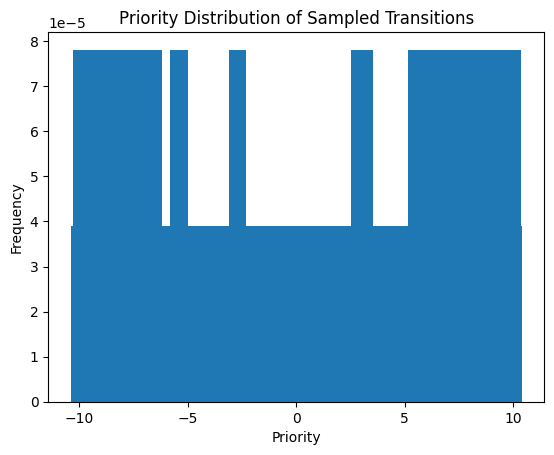

In [87]:
import time

N = int(10e6)

# Sample N batches of X transitions and measure the time, save all samples and plot the priority distribution
import matplotlib.pyplot as plt

# Add N transitions to the sum tree
sum_tree = SumTree(N)
start_time = time.time()
for i in range(N):
    prio = np.random.uniform(-10, 10)
    sum_tree.add(prio, f"transition_{i}")
end_time = time.time()
print(f"Time taken to add {N} transitions: {end_time - start_time:.2f} seconds")
print(f"For 10000 Samples it took {10000*(end_time - start_time)/N:.2f} seconds")

# Sample N batches of X transitions
num_batches = 100
batch_size = 256
samples = [[], [], []]

start_time = time.time()
for _ in range(num_batches):
    # batch = sum_tree.sample_batch(batch_size)
    prios, data = sum_tree.get_all_leafs()
    props = np.array(prios)
    props = np.abs(props) / np.sum(np.abs(props))
    s = np.random.choice(range(sum_tree.size), batch_size, p=props)

    batch = [data[s], prios[s], props[s]]
    for i in range(3):
        samples[i].extend(batch[i])
end_time = time.time()

# Measure the time taken
time_taken = end_time - start_time
print(
    f"Time taken to sample {num_batches} batches of {batch_size} transitions: {time_taken:.2f} seconds"
)
print(f"For 1 Batch it took {time_taken/(num_batches*batch_size):.2f} seconds")

# Extract priorities from samples
priorities = samples[1]
num_occurrences = {p: priorities.count(p) for p in set(priorities)}

rel_freq = {p: num_occurrences[p] / len(priorities) for p in num_occurrences}

# Plot the priority distribution
plt.bar(rel_freq.keys(), rel_freq.values())
plt.title("Priority Distribution of Sampled Transitions")
plt.xlabel("Priority")
plt.ylabel("Frequency")
plt.show()